In [1]:
import sys
sys.path.insert(0, '../')
import data_generation.SimulatorWaveEquation as simu
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs 
import matplotlib.tri as mtri
import weather_model_graphs as wmg 
from data_generation import DataPlotter as dp


c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
R = 1 # Radius
C = 1 # Wave speed 
Lmax = 5 # Maximum degree of spherical harmonics 
tmax = 10 # Maximum time  
generations = 1 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse
omega = C/R*np.sqrt(Lmax*(Lmax+1)) 
T_period = 2*np.pi/omega
dt = T_period/10 # Time step 
print("dt =", dt) 

dt = 0.11471474419090952


In [3]:
# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

In [12]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations,dt=dt)
ds = sim.simulate(title=None, savedata=False, savegraph=False)  # (time, N) 

long = ds['lon'].values
lat = ds['lat'].values
tri = ds['tri'].values

coords = np.stack([long, lat], axis=1)   # (N,2) 


2026-03-11 10:12:41.831 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:123 - Projecting coords from CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) to CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) for graph creation.


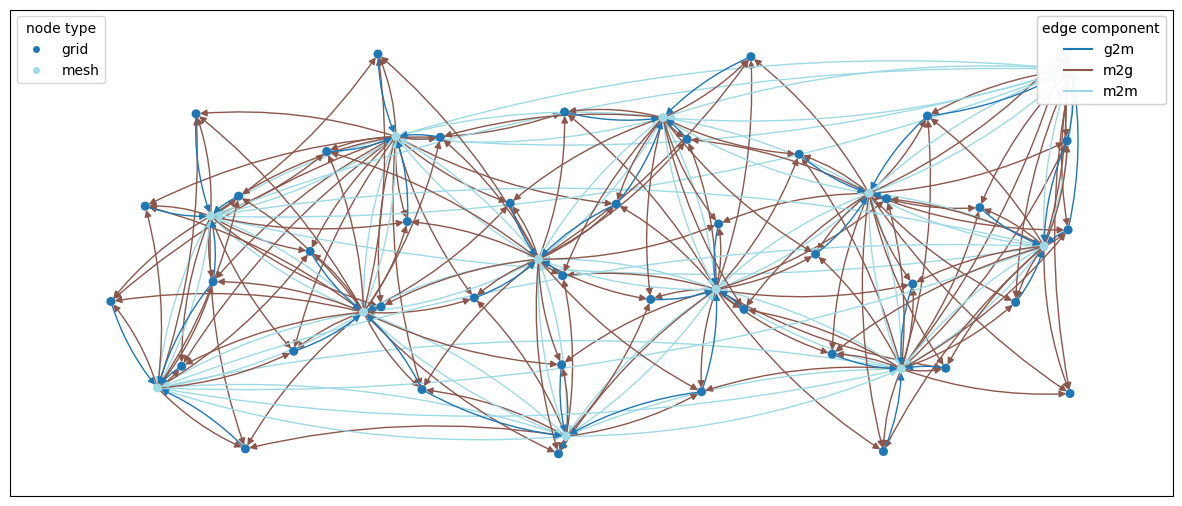

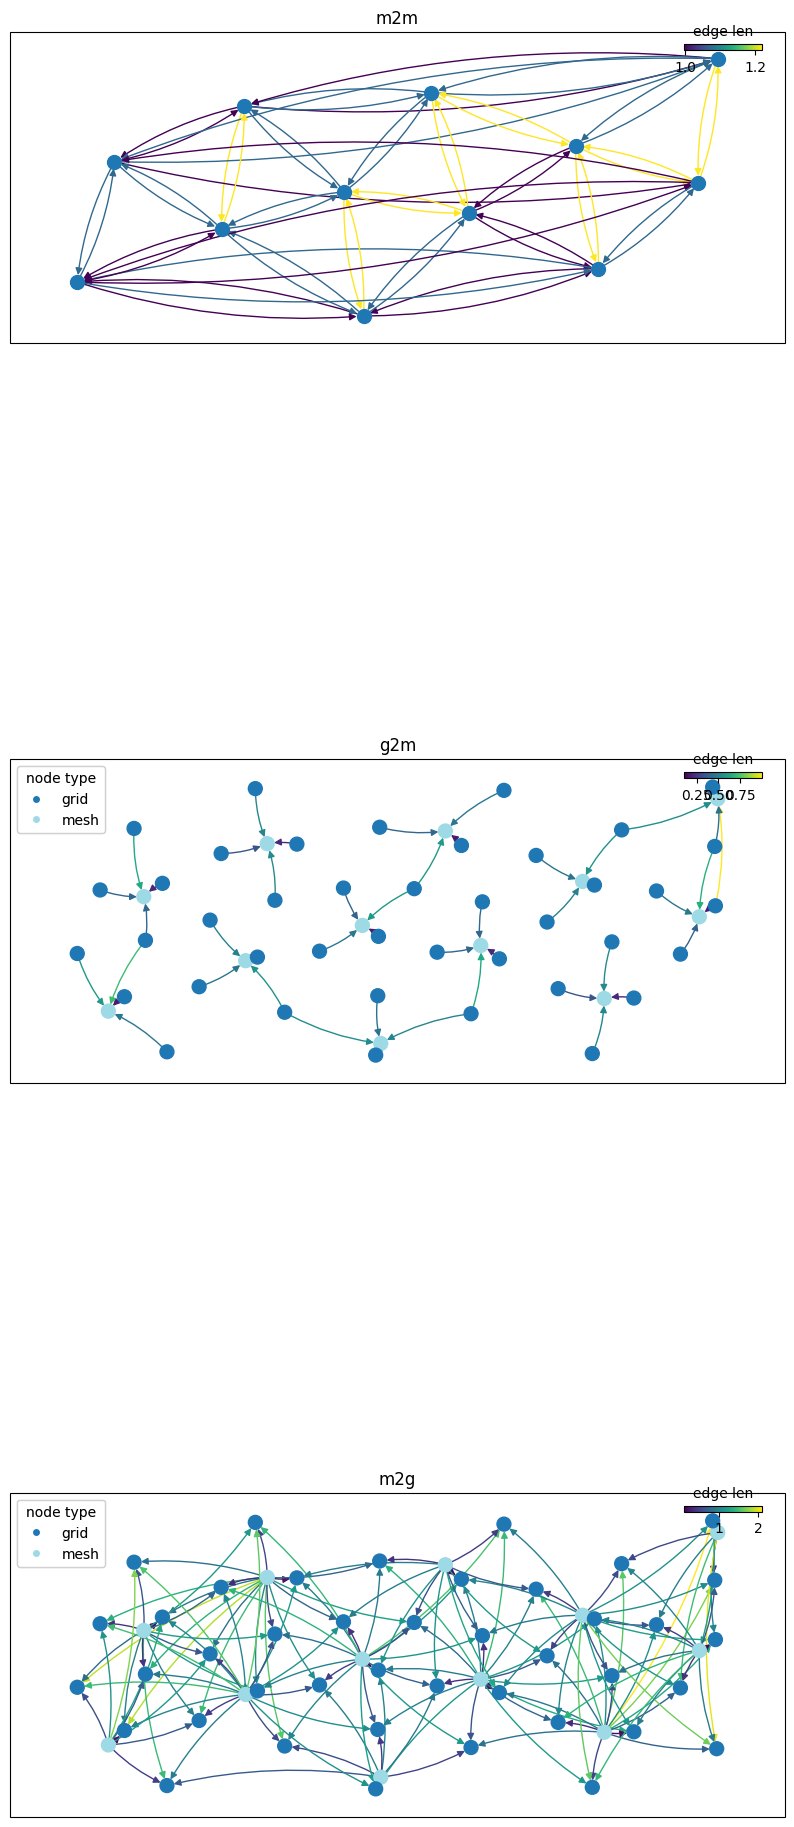

In [13]:
graph_keisler = wmg.create.archetype.create_keisler_graph(coords, mesh_node_distance=0.5,coords_crs=ccrs.PlateCarree(),graph_crs=ccrs.PlateCarree())
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph_keisler, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)

graph_components = wmg.split_graph_by_edge_attribute(graph=graph_keisler, attr="component")

n_components = len(graph_components)
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(10, 9 * n_components), subplot_kw={"projection": ccrs.PlateCarree()})

for (name, g), ax in zip(graph_components.items(), axes.flatten()):
    pl_kwargs = {}
    if name == "m2m":
        pl_kwargs = dict(edge_color_attr="len") 
    elif name == "g2m" or name == "m2g":
        pl_kwargs = dict(edge_color_attr="len", node_color_attr="type")

    wmg.visualise.nx_draw_with_pos_and_attr(graph=g, ax=ax, **pl_kwargs)
    ax.set_title(name)
    ax.set_aspect(1.0)


In [ ]:
print(graph_components["m2m"].nodes)
print(graph_components["m2m"].edges)


[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
[(42, 49), (42, 45), (42, 43), (42, 51), (42, 44), (43, 53), (43, 42), (43, 49), (43, 52), (43, 51), (44, 51), (44, 45), (44, 42), (44, 46), (44, 50), (45, 46), (45, 42), (45, 48), (45, 44), (45, 49), (46, 45), (46, 48), (46, 44), (46, 47), (46, 50), (47, 48), (47, 53), (47, 50), (47, 52), (47, 46), (48, 47), (48, 53), (48, 49), (48, 45), (48, 46), (49, 42), (49, 48), (49, 53), (49, 43), (49, 45), (50, 52), (50, 47), (50, 51), (50, 44), (50, 46), (51, 44), (51, 42), (51, 50), (51, 43), (51, 52), (52, 53), (52, 50), (52, 43), (52, 47), (52, 51), (53, 48), (53, 52), (53, 43), (53, 47), (53, 49)]


In [25]:
graph_components["m2m"].nodes(data=True)

NodeDataView({42: {'xyz': array([ 0.16155752, -0.73288817,  0.66088887]), 'pos': array([-1.35382682,  0.72200255]), 'type': 'mesh'}, 43: {'xyz': array([-0.78319237, -0.57940245,  0.22561586]), 'pos': array([-2.50465426,  0.22757515]), 'type': 'mesh'}, 44: {'xyz': array([ 0.89220282, -0.44983677, -0.04026172]), 'pos': array([-0.46699133, -0.04027261]), 'type': 'mesh'}, 45: {'xyz': array([0.6364346 , 0.20149167, 0.74454825]), 'pos': array([0.30661069, 0.83985788]), 'type': 'mesh'}, 46: {'xyz': array([ 0.78319237,  0.57940245, -0.22561586]), 'pos': array([ 0.6369384 , -0.22757515]), 'type': 'mesh'}, 47: {'xyz': array([-0.16155752,  0.73288817, -0.66088887]), 'pos': array([ 1.78776583, -0.72200255]), 'type': 'mesh'}, 48: {'xyz': array([-0.0148251 ,  0.93245588,  0.36097958]), 'pos': array([1.58669398, 0.36931808]), 'type': 'mesh'}, 49: {'xyz': array([-0.39901657,  0.12141567,  0.90886964]), 'pos': array([2.84620722, 1.14056582]), 'type': 'mesh'}, 50: {'xyz': array([ 0.39901657, -0.12141567

In [26]:
graph_components["m2m"].edges(data=True)

OutEdgeDataView([(42, 49, {'len': np.float64(1.1071487177940902), 'vdiff': array([ 0.56057409, -0.85430384, -0.24798076]), 'component': 'm2m'}), (42, 45, {'len': np.float64(1.1071487177940904), 'vdiff': array([-0.47487708, -0.93437983, -0.08365938]), 'component': 'm2m'}), (42, 43, {'len': np.float64(1.1071487177940902), 'vdiff': array([ 0.94474989, -0.15348571,  0.43527302]), 'component': 'm2m'}), (42, 51, {'len': np.float64(1.1071487177940909), 'vdiff': array([0.14673242, 0.19956771, 1.02186845]), 'component': 'm2m'}), (42, 44, {'len': np.float64(1.1071487177940904), 'vdiff': array([-0.7306453 , -0.2830514 ,  0.70115059]), 'component': 'm2m'}), (43, 53, {'len': np.float64(1.1071487177940902), 'vdiff': array([ 0.10901046, -1.02923922,  0.18535414]), 'component': 'm2m'}), (43, 42, {'len': np.float64(1.1071487177940902), 'vdiff': array([-0.94474989,  0.15348571, -0.43527302]), 'component': 'm2m'}), (43, 49, {'len': np.float64(1.1071487177940904), 'vdiff': array([-0.3841758 , -0.70081812,

# Generation = 0 for both mesh and grid 

In [9]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=0,dt=dt)
ds = sim.simulate(title=None, savedata=False, savegraph=False)  # (time, N) 

long = ds['lon'].values
lat = ds['lat'].values
tri = ds['tri'].values

coords = np.stack([long, lat], axis=1)   # (N,2) 


2026-03-11 10:11:19.058 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:123 - Projecting coords from CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) to CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) for graph creation.


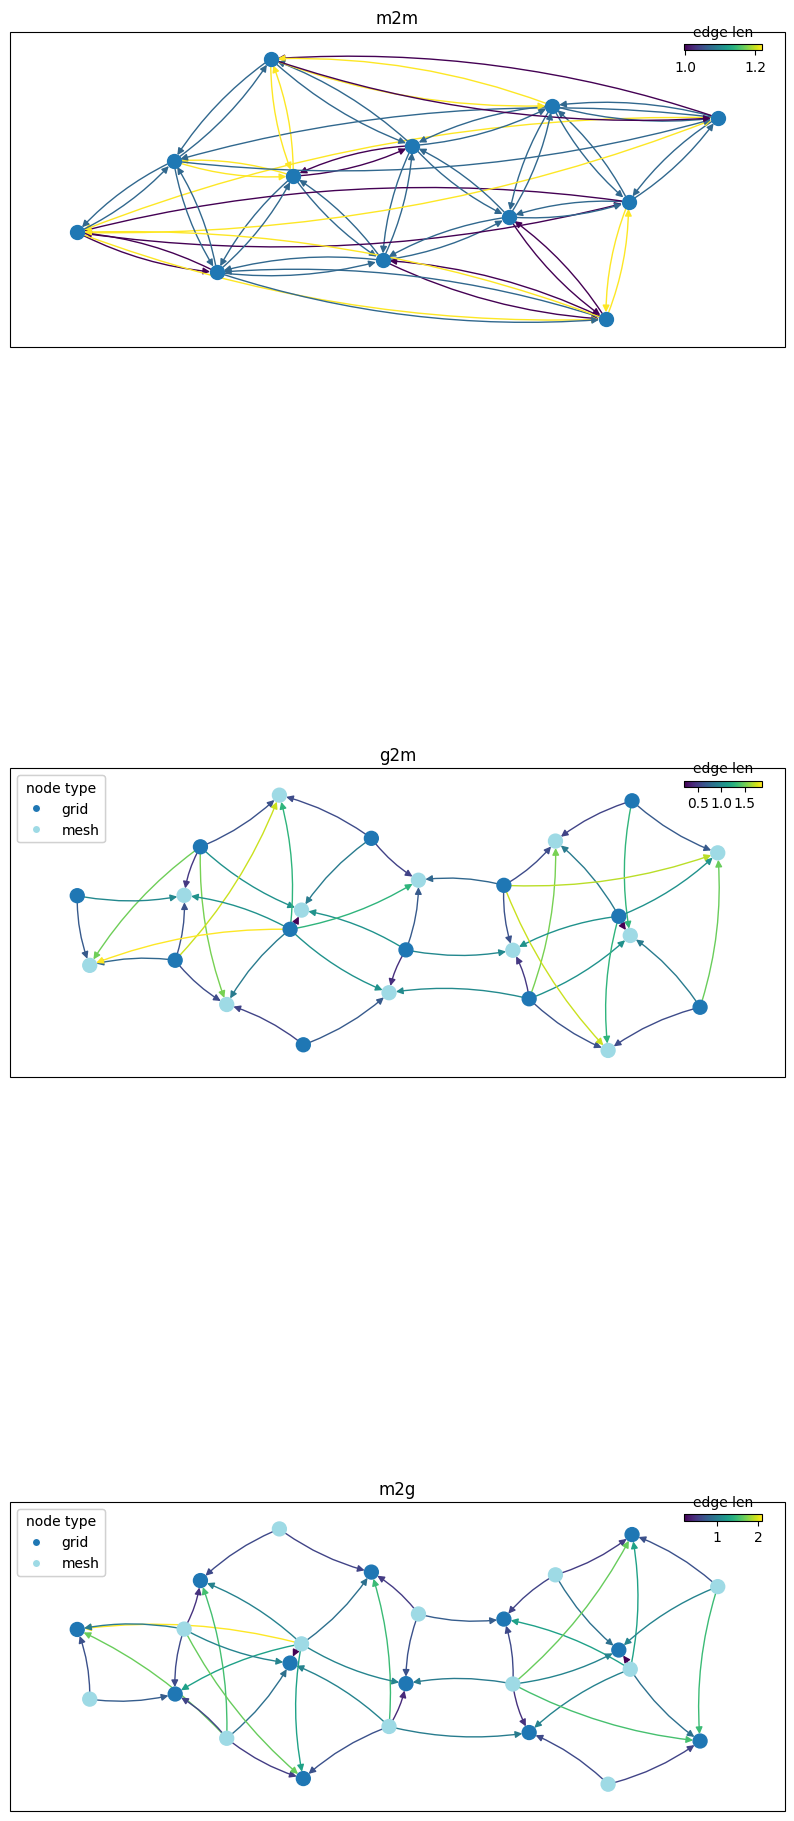

In [11]:
graph_keisler = wmg.create.archetype.create_keisler_graph(coords, mesh_node_distance=0.5,coords_crs=ccrs.PlateCarree(),graph_crs=ccrs.PlateCarree())

graph_components = wmg.split_graph_by_edge_attribute(graph=graph_keisler, attr="component")
n_components = len(graph_components)
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(10, 9 * n_components), subplot_kw={"projection": ccrs.PlateCarree()})

for (name, g), ax in zip(graph_components.items(), axes.flatten()):
    pl_kwargs = {}
    if name == "m2m":
        pl_kwargs = dict(edge_color_attr="len") 
    elif name == "g2m" or name == "m2g":
        pl_kwargs = dict(edge_color_attr="len", node_color_attr="type")

    wmg.visualise.nx_draw_with_pos_and_attr(graph=g, ax=ax, **pl_kwargs)
    ax.set_title(name)
    ax.set_aspect(1.0)
